In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import cartopy.crs as ccrs
import cmocean

In [2]:
from OceanDataStore import OceanDataCatalog

In [3]:
catalog = OceanDataCatalog(catalog_name="noc-model-stac")

In [4]:
catalog.available_collections

['noc-rapid-evolution', 'noc-npd-jra55', 'noc-npd-era5']

In [5]:
catalog.search(collection='noc-npd-era5', standard_name='sea_surface_temperature')


            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1y
              Title: eORCA1 ERA5v1 NPD T1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics annual mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2024-12-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1m
              Title: eORCA1 ERA5v1 NPD T1m Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics monthly mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2024-12-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca025-era5v1/gn/T1y_3d
              Title: eORCA025 ERA5v1 NPD T1y_3d Icechunk repository
              Description: Icechunk repository containing eORCA025 ERA5v1 

In [6]:
catalog.available_items

['noc-npd-era5/npd-eorca1-era5v1/gn/T1y',
 'noc-npd-era5/npd-eorca1-era5v1/gn/T1m',
 'noc-npd-era5/npd-eorca025-era5v1/gn/T1y_3d',
 'noc-npd-era5/npd-eorca025-era5v1/gn/T1m_3d',
 'noc-npd-era5/npd-eorca025-era5v1/gn/T5d_3d',
 'noc-npd-era5/npd-eorca12-era5v1/gn/T1y_3d',
 'noc-npd-era5/npd-eorca12-era5v1/gn/T1m_3d']

In [7]:
catalog.Items[0]

<Item id=noc-npd-era5/npd-eorca1-era5v1/gn/T1y>

In [8]:
ds1 = catalog.open_dataset(id=catalog.Items[0].id,
                          start_datetime='1980-01',
                          end_datetime='1990-12',  
                           bbox = (-85.0, 0.0, 0.0, 80.0))

ds1

<xarray.Dataset> Size: 869MB
Dimensions:                (time_counter: 11, y: 135, x: 85, deptht: 75,
                            axis_nbounds: 2)
Coordinates:
  * deptht                 (deptht) float32 300B 0.5058 1.556 ... 5.902e+03
    nav_lat                (y, x) float64 92kB 0.0 0.0 0.0 ... 80.05 79.65 79.25
    nav_lon                (y, x) float64 92kB -84.5 -83.5 -82.5 ... 45.74 46.87
  * time_counter           (time_counter) datetime64[ns] 88B 1980-07-02 ... 1...
    time_centered          (time_counter) datetime64[ns] 88B dask.array<chunksize=(1,), meta=np.ndarray>
Dimensions without coordinates: y, x, axis_nbounds
Data variables: (12/74)
    berg_latent_heat_flux  (time_counter, y, x) float32 505kB dask.array<chunksize=(1, 135, 85), meta=np.ndarray>
    evs                    (time_counter, y, x) float32 505kB dask.array<chunksize=(1, 135, 85), meta=np.ndarray>
    ficeberg               (time_counter, y, x) float32 505kB dask.array<chunksize=(1, 135, 85), meta=np.ndarray>
    hfevapds               (time_counter, y, x) float32 505kB dask.array<chunksize=(1, 135, 85), meta=np.ndarray>
    hfempds                (time_counter, y, x) float32 505kB dask.array<chunksize=(1, 135, 85), meta=np.ndarray>
    hfns                   (time_counter, y, x) float32 505kB dask.array<chunksize=(1, 135, 85), meta=np.ndarray>
    ...                     ...
    vohfcisf               (time_counter, deptht, y, x) float32 38MB dask.array<chunksize=(1, 25, 135, 85), meta=np.ndarray>
    vowflisf               (time_counter, deptht, y, x) float32 38MB dask.array<chunksize=(1, 25, 135, 85), meta=np.ndarray>
    ttrd_atf_li            (time_counter, deptht, y, x) float32 38MB dask.array<chunksize=(1, 25, 135, 85), meta=np.ndarray>
    zossq                  (time_counter, y, x) float32 505kB dask.array<chunksize=(1, 135, 85), meta=np.ndarray>
    ttrd_evd_li            (time_counter, deptht, y, x) float32 38MB dask.array<chunksize=(1, 25, 135, 85), meta=np.ndarray>
    ttrd_qns_li            (time_counter, y, x) float32 505kB dask.array<chunksize=(1, 135, 85), meta=np.ndarray>

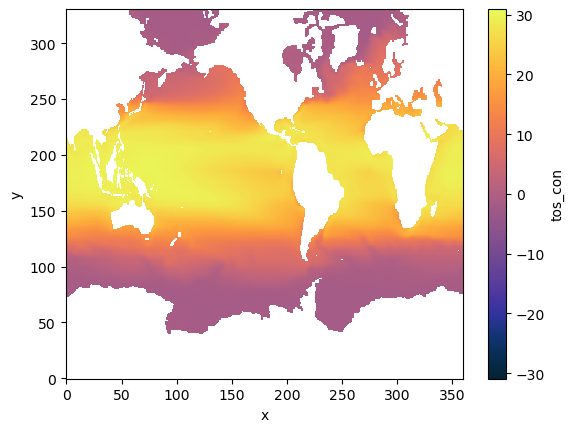

In [9]:
## First Plot to test - entire map, time averaged between 1980 - 1990

ds1['tos_con'].mean(dim='time_counter').plot(cmap=cmocean.cm.thermal)

In [10]:
## Looking just at the North Atlantic 

ds2 = catalog.open_dataset(id=catalog.Items[0].id,
                          start_datetime='1980-01',
                          end_datetime='1990-12', 
                          bbox = (-85.0, 0.0, 0.0, 80.0))


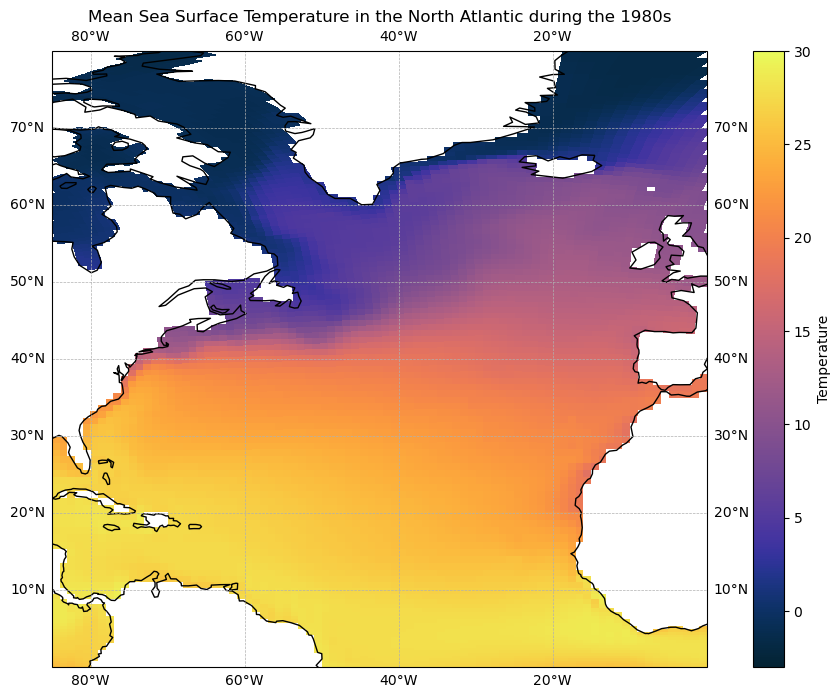

In [23]:
## Plotting North Atlantic using cartopy 

fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

data = ds2['tos_con'].mean(dim='time_counter')
im = ax.pcolormesh(ds2['nav_lon'],  ds2['nav_lat'], data, cmap=cmocean.cm.thermal, transform=ccrs.PlateCarree(), vmin = -3, vmax = 30)
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
ax.coastlines()
ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
ax.set_title('Mean Sea Surface Temperature in the North Atlantic during the 1980s')

plt.colorbar(im, ax=ax, label='Temperature')
plt.show()

Text(0.5, 1.0, 'Mean Sea Surface Temperature')

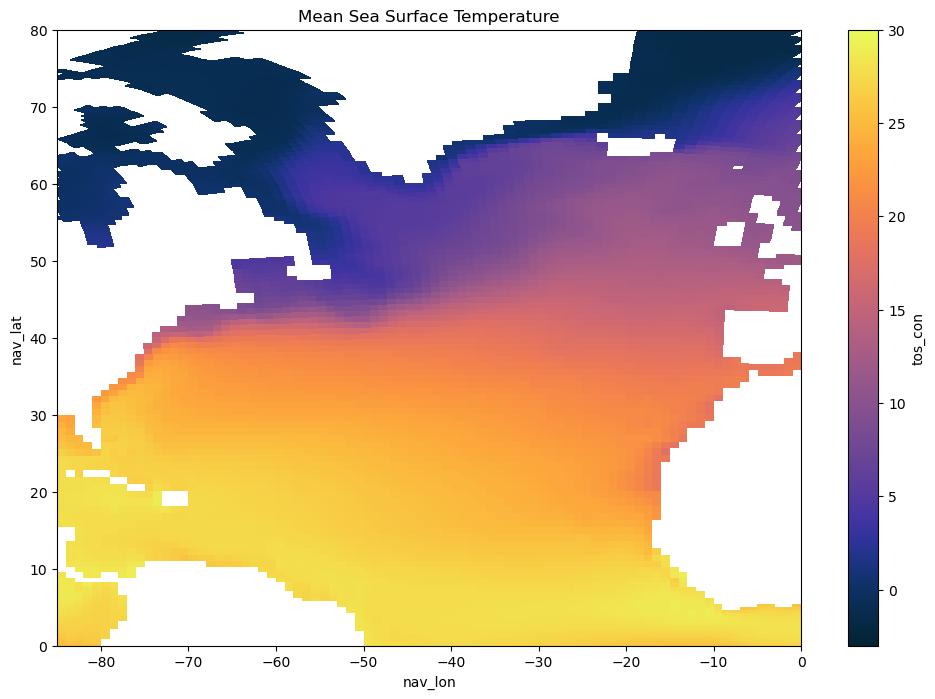

In [22]:
## Plotting North Atlantic using default map 

fig, ax = plt.subplots(figsize = (12, 8))
ds2['tos_con'].mean(dim='time_counter').plot(x='nav_lon', y='nav_lat', ax = ax, cmap=cmocean.cm.thermal, vmin = -3, vmax = 30)
ax.set_xlim(-85.0, 0.0)   # Your bbox lon range
ax.set_ylim(0.0, 80.0)
ax.set_title('Mean Sea Surface Temperature')

In [14]:
ds2

<xarray.Dataset> Size: 862MB
Dimensions:                (time_counter: 11, y: 135, x: 85, deptht: 75,
                            axis_nbounds: 2)
Coordinates:
  * deptht                 (deptht) float32 300B 0.5058 1.556 ... 5.902e+03
    nav_lat                (y, x) float64 92kB 0.0 0.0 0.0 ... 80.05 79.65 79.25
    nav_lon                (y, x) float64 92kB -84.5 -83.5 -82.5 ... 45.74 46.87
    time_centered          (time_counter) datetime64[ns] 88B dask.array<chunksize=(1,), meta=np.ndarray>
  * time_counter           (time_counter) datetime64[ns] 88B 1980-07-02 ... 1...
Dimensions without coordinates: y, x, axis_nbounds
Data variables: (12/73)
    berg_latent_heat_flux  (time_counter, y, x) float32 505kB dask.array<chunksize=(1, 135, 85), meta=np.ndarray>
    hfevapds               (time_counter, y, x) float32 505kB dask.array<chunksize=(1, 135, 85), meta=np.ndarray>
    fsitherm               (time_counter, y, x) float32 505kB dask.array<chunksize=(1, 135, 85), meta=np.ndarray>
    friver                 (time_counter, y, x) float32 505kB dask.array<chunksize=(1, 135, 85), meta=np.ndarray>
    empmr                  (time_counter, y, x) float32 505kB dask.array<chunksize=(1, 135, 85), meta=np.ndarray>
    ficeberg               (time_counter, y, x) float32 505kB dask.array<chunksize=(1, 135, 85), meta=np.ndarray>
    ...                     ...
    tos_con                (time_counter, y, x) float32 505kB dask.array<chunksize=(1, 135, 85), meta=np.ndarray>
    vohfcisf               (time_counter, deptht, y, x) float32 38MB dask.array<chunksize=(1, 25, 135, 85), meta=np.ndarray>
    tnpeo                  (time_counter, y, x) float32 505kB dask.array<chunksize=(1, 135, 85), meta=np.ndarray>
    zos                    (time_counter, y, x) float32 505kB dask.array<chunksize=(1, 135, 85), meta=np.ndarray>
    vowflisf               (time_counter, deptht, y, x) float32 38MB dask.array<chunksize=(1, 25, 135, 85), meta=np.ndarray>
    zossq                  (time_counter, y, x) float32 505kB dask.array<chunksize=(1, 135, 85), meta=np.ndarray>

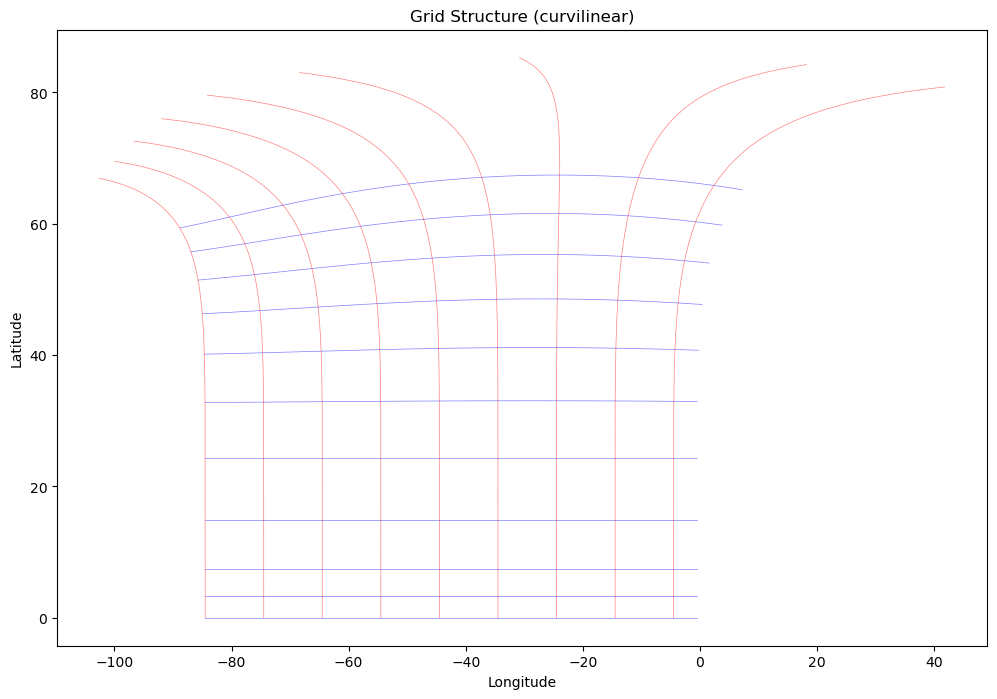

In [15]:
#### What does a Curvilinear grid look like?

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 8))

for i in range(0, 106, 10):
    ax.plot(ds2['nav_lon'][i, :], ds2['nav_lat'][i, :], 'b-', alpha=0.5, linewidth=0.5)
    
for j in range(0, 90, 10):
    ax.plot(ds2['nav_lon'][:, j], ds2['nav_lat'][:, j], 'r-', alpha=0.5, linewidth=0.5)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Grid Structure (curvilinear)')
plt.show()